Wild-type 'GSGQNQQ' enrichment scores: rep1=1.57, rep2=1.53, rep3=2.99
Wild-type mean enrichment: 2.03 ± 0.48


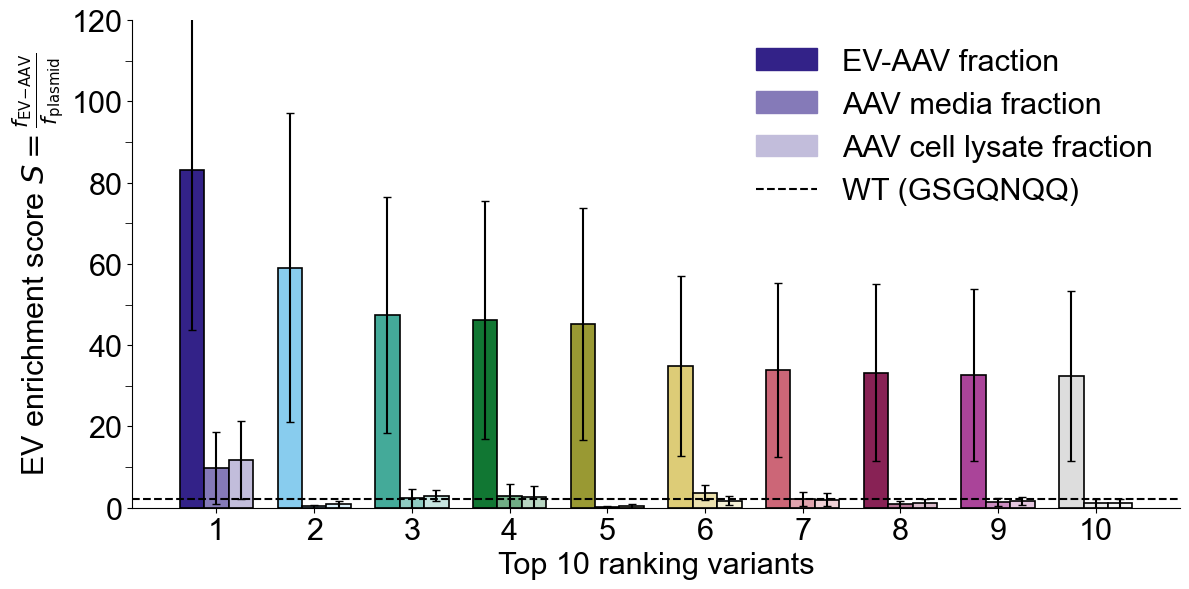

In [ ]:
## ML-Assisted DE Approach - Barplot with Arithmetic Mean and Standard Error

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
from scipy import stats
from matplotlib import rcParams
from matplotlib import colors as mcolors

# ───────────────────── USER SETTINGS ─────────────────────
xlsx_path = ("data/Excel/ml_assessment_library/EVAAV/enrichment_score_with_amino_acid_sequence.xlsx")
xlsx_path_AAV = ("data/Excel/ml_assessment_library/AAV_media/enrichment_scores_with_amino_acid_sequence.xlsx")
xlsx_path_CL = ("data/Excel/ml_assessment_library/AAV_cell_lysate/enrichment_scores_with_amino_acid_sequence.xlsx")

rep_cols = [
    "enrichment_score_rep_1",
    "enrichment_score_rep_2",
    "enrichment_score_rep_3",
]

# Paul Tol "Notes" palette (Fig. 4): indigo, cyan, teal, green, olive, sand, rose, wine, purple, pale grey
tol_notes = [
    "#332288", "#88CCEE", "#44AA99", "#117733", "#999933",
    "#DDCC77", "#CC6677", "#882255", "#AA4499", "#DDDDDD"
]

# ───────────── LOAD & PREP DATA ─────────────
df = pd.read_excel(xlsx_path)
df_AAV = pd.read_excel(xlsx_path_AAV)
df_CL = pd.read_excel(xlsx_path_CL)

# Group by amino acid sequence and calculate mean for each replicate
avg_scores = df.groupby('amino_acid_sequence')[rep_cols].mean().reset_index()
avg_scores_AAV = df_AAV.groupby('amino_acid_sequence')[rep_cols].mean().reset_index()
avg_scores_CL = df_CL.groupby('amino_acid_sequence')[rep_cols].mean().reset_index()

# create replicate-specific dataframes including sequence
# and compute ranks based on score only

df_rep1 = avg_scores[['amino_acid_sequence','enrichment_score_rep_1']].copy()
df_rep2 = avg_scores[['amino_acid_sequence','enrichment_score_rep_2']].copy()
df_rep3 = avg_scores[['amino_acid_sequence','enrichment_score_rep_3']].copy()

df_rep1['rank'] = df_rep1['enrichment_score_rep_1'].rank(method='first')
df_rep1.sort_values('rank', ascending=False, inplace=True)
df_rep2['rank'] = df_rep2['enrichment_score_rep_2'].rank(method='first')
df_rep2.sort_values('rank', ascending=False, inplace=True)
df_rep3['rank'] = df_rep3['enrichment_score_rep_3'].rank(method='first')
df_rep3.sort_values('rank', ascending=False, inplace=True)

# merge and keep sequences for each replicate with explicit column names

df_combined = (
    df_rep1.rename(columns={'amino_acid_sequence':'sequence_rep_1'})
    .merge(df_rep2.rename(columns={'amino_acid_sequence':'sequence_rep_2'}), on='rank', how='inner')
    .merge(df_rep3.rename(columns={'amino_acid_sequence':'sequence_rep_3'}), on='rank', how='inner')
)

# Calculate arithmetic mean and standard error across replicates
df_combined["arithmetic_mean_enrichment"] = df_combined[rep_cols].mean(axis=1)
df_combined["std_error"] = df_combined[rep_cols].sem(axis=1)

# Retrieve top ranked variants for statistical testing
top_ml_scores = np.array([
    df_combined.iloc[0]["enrichment_score_rep_1"],
    df_combined.iloc[0]["enrichment_score_rep_2"],
    df_combined.iloc[0]["enrichment_score_rep_3"]
])

top10_df = df_combined.head(10).reset_index(drop=True)

# look up enrichment for each sequence column in AAV/CL and add to top10_df

def lookup_mean(seq, avg_df):
    row = avg_df[avg_df['amino_acid_sequence'] == seq]
    if row.empty:
        return np.nan
    return row[rep_cols].mean(axis=1).iloc[0]

for i in range(1, 4):
    seq_col = f"sequence_rep_{i}"
    top10_df[f"aav_mean_{i}"] = top10_df[seq_col].apply(lambda s: lookup_mean(s, avg_scores_AAV))
    top10_df[f"cl_mean_{i}"] = top10_df[seq_col].apply(lambda s: lookup_mean(s, avg_scores_CL))

# replace NaNs with zero in individual means before computing row means
top10_df[[f'aav_mean_{i}' for i in range(1,4)]] = top10_df[[f'aav_mean_{i}' for i in range(1,4)]].fillna(0)
top10_df[[f'cl_mean_{i}' for i in range(1,4)]] = top10_df[[f'cl_mean_{i}' for i in range(1,4)]].fillna(0)

# compute row-wise arithmetic mean enrichment for AAV and CL
top10_df['aav_mean_all'] = top10_df[[f'aav_mean_{i}' for i in range(1,4)]].mean(axis=1)
top10_df['cl_mean_all'] = top10_df[[f'cl_mean_{i}' for i in range(1,4)]].mean(axis=1)

# compute standard error across the three replicate means for AAV and CL
top10_df['aav_se_all'] = top10_df[[f'aav_mean_{i}' for i in range(1,4)]].sem(axis=1)
top10_df['cl_se_all'] = top10_df[[f'cl_mean_{i}' for i in range(1,4)]].sem(axis=1)

# ─── WILD-TYPE REFERENCE ───
wt_seq = "GSGQNQQ"
wt_row = avg_scores[avg_scores['amino_acid_sequence'] == wt_seq]
if not wt_row.empty:
    wt_scores = wt_row[rep_cols].values[0]
    wt_mean = float(wt_scores.mean())
    wt_se = float(wt_scores.std(ddof=1) / np.sqrt(len(wt_scores)))
    print(f"Wild-type '{wt_seq}' enrichment scores: rep1={wt_scores[0]:.2f}, rep2={wt_scores[1]:.2f}, rep3={wt_scores[2]:.2f}")
    print(f"Wild-type mean enrichment: {wt_mean:.2f} ± {wt_se:.2f}")
else:
    wt_mean = None
    print(f"Wild-type sequence '{wt_seq}' not found in ML data.")

# ─────────────── STYLE CONSTANTS ───────────────
base_fs = 22
rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.titlesize": base_fs,
    "axes.labelsize": base_fs,
    "xtick.labelsize": base_fs,
    "ytick.labelsize": base_fs,
    "legend.fontsize": base_fs,
})

# ───────────────────── PLOT ─────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top10_df))
width = 0.25  # width of each bar

# mix with white: fractions for media and lysate
def lighten(col, frac):
    return tuple(col[i] + (1-col[i])*frac for i in range(3))

for xi in x:
    col_ev = mcolors.to_rgb(tol_notes[xi])
    col_media = lighten(col_ev, 0.4)
    col_lysate = lighten(col_ev, 0.7)
    ax.bar(xi - width, top10_df.loc[xi, "arithmetic_mean_enrichment"], width,
            color=col_ev, edgecolor="black", linewidth=1.2,
            yerr=top10_df.loc[xi, "std_error"], capsize=3)
    ax.bar(xi, top10_df.loc[xi, "aav_mean_all"], width,
            color=col_media, edgecolor="black", linewidth=1.2,
            yerr=top10_df.loc[xi, "aav_se_all"], capsize=3)
    ax.bar(xi + width, top10_df.loc[xi, "cl_mean_all"], width,
            color=col_lysate, edgecolor="black", linewidth=1.2,
            yerr=top10_df.loc[xi, "cl_se_all"], capsize=3)

if wt_mean is not None:
    ax.axhline(wt_mean, color='black', linestyle='--', linewidth=1.5)

# (scatter points removed)

ax.set_xlabel("Top 10 ranking variants", fontsize=base_fs)
ax.set_ylabel(r"EV enrichment score $S = \frac{f_{\mathrm{EV\!-\!AAV}}}{f_{\mathrm{plasmid}}}$", fontsize=base_fs)
ax.set_xticks(x)
ax.set_xticklabels([f"{i+1}" for i in x])

col_ev_0 = mcolors.to_rgb(tol_notes[0])
handles = [
    mpatches.Patch(color=col_ev_0, label="EV-AAV fraction"),
    mpatches.Patch(color=lighten(col_ev_0, 0.4), label="AAV media fraction"),
    mpatches.Patch(color=lighten(col_ev_0, 0.7), label="AAV cell lysate fraction"),
]
if wt_mean is not None:
    handles.append(mlines.Line2D([], [], color='black', linestyle='--', linewidth=1.5, label=f"WT ({wt_seq})"))
legend = ax.legend(handles=handles, frameon=False)

# add minor ticks at specified y-values
minor_ticks = [10, 30, 50, 70, 90, 110]
ax.set_yticks(minor_ticks, minor=True)
ax.set_ylim(0, 120)
ax.tick_params(axis='y', which='minor', length=5)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plots/figure_3a_i.png')
plt.show()

Wild-type 'GSGQNQQ' % EV-AAV: 29.6% ± 4.7%


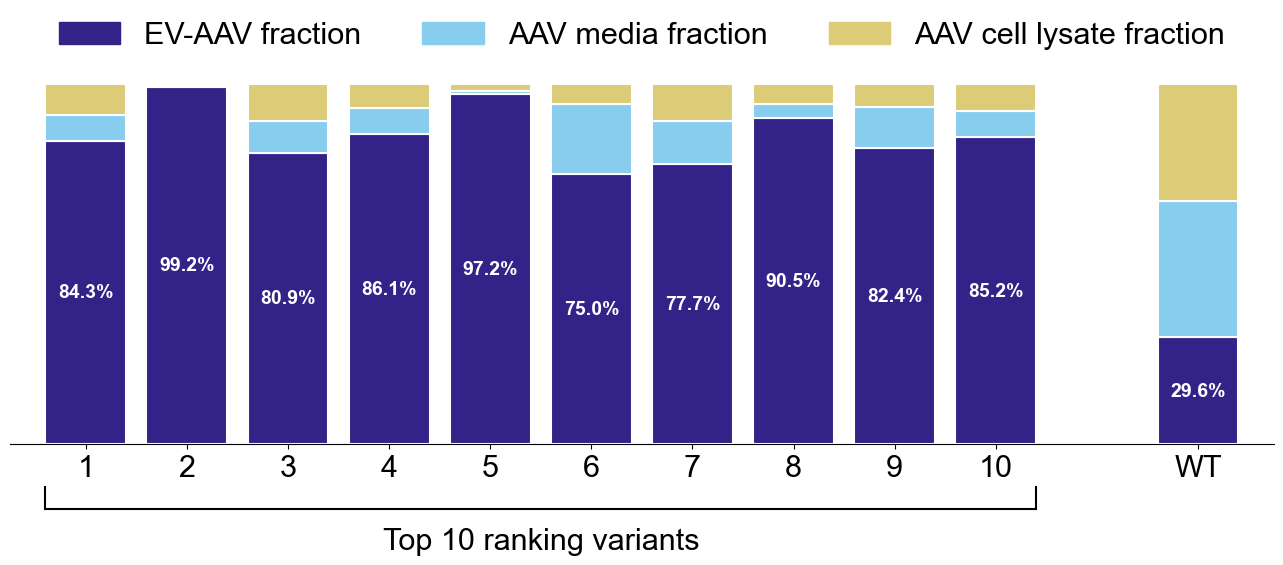

In [2]:
## ML-Assisted DE Approach — EV-AAV fraction as % of total AAV
# Enrichment scores are linear ratios; percentages are computed directly.
# Note: variants absent from the AAV/CL data have their score imputed as 0.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams

# ─── CALCULATE PER-REPLICATE PERCENTAGES FOR TOP 10 ───
pct_df = top10_df.copy()

for i in range(1, 4):
    ev    = top10_df[f"enrichment_score_rep_{i}"]
    aav   = top10_df[f"aav_mean_{i}"]
    cl    = top10_df[f"cl_mean_{i}"]
    total = ev + aav + cl
    pct_df[f"pct_ev_{i}"]  = ev  / total * 100
    pct_df[f"pct_aav_{i}"] = aav / total * 100
    pct_df[f"pct_cl_{i}"]  = cl  / total * 100

pct_df["pct_ev_mean"]  = pct_df[["pct_ev_1",  "pct_ev_2",  "pct_ev_3"]].mean(axis=1)
pct_df["pct_aav_mean"] = pct_df[["pct_aav_1", "pct_aav_2", "pct_aav_3"]].mean(axis=1)
pct_df["pct_cl_mean"]  = pct_df[["pct_cl_1",  "pct_cl_2",  "pct_cl_3"]].mean(axis=1)
pct_df["pct_ev_se"]    = pct_df[["pct_ev_1",  "pct_ev_2",  "pct_ev_3"]].sem(axis=1)

# ─── WILD-TYPE PERCENTAGES ───
wt_row_ev  = avg_scores[avg_scores['amino_acid_sequence'] == wt_seq]
wt_row_aav = avg_scores_AAV[avg_scores_AAV['amino_acid_sequence'] == wt_seq]
wt_row_cl  = avg_scores_CL[avg_scores_CL['amino_acid_sequence'] == wt_seq]

if not wt_row_ev.empty:
    wt_aav_score = wt_row_aav[rep_cols].mean(axis=1).values[0] if not wt_row_aav.empty else 0
    wt_cl_score  = wt_row_cl[rep_cols].mean(axis=1).values[0]  if not wt_row_cl.empty  else 0
    wt_pct_ev_reps, wt_pct_aav_reps, wt_pct_cl_reps = [], [], []
    for i in range(1, 4):
        wt_ev    = wt_row_ev[f"enrichment_score_rep_{i}"].values[0]
        wt_total = wt_ev + wt_aav_score + wt_cl_score
        wt_pct_ev_reps.append(wt_ev        / wt_total * 100)
        wt_pct_aav_reps.append(wt_aav_score / wt_total * 100)
        wt_pct_cl_reps.append(wt_cl_score   / wt_total * 100)
    wt_pct_ev_mean  = float(np.mean(wt_pct_ev_reps))
    wt_pct_aav_mean = float(np.mean(wt_pct_aav_reps))
    wt_pct_cl_mean  = float(np.mean(wt_pct_cl_reps))
    wt_pct_ev_se    = float(np.std(wt_pct_ev_reps, ddof=1) / np.sqrt(3))
    print(f"Wild-type '{wt_seq}' % EV-AAV: {wt_pct_ev_mean:.1f}% ± {wt_pct_ev_se:.1f}%")
else:
    wt_pct_ev_mean = wt_pct_aav_mean = wt_pct_cl_mean = None
    print(f"Wild-type '{wt_seq}' not found in ML data.")

# ─── STYLE CONSTANTS ───
base_fs = 22
rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.titlesize": base_fs,
    "axes.labelsize": base_fs,
    "xtick.labelsize": base_fs,
    "ytick.labelsize": base_fs,
    "legend.fontsize": base_fs,
})

col_ev  = "#332288"
col_aav = "#88CCEE"
col_cl  = "#DDCC77"
width   = 0.8   # wider bars so the direct percentage label is readable

# ─── STACKED 100% BAR CHART ───
fig, ax = plt.subplots(figsize=(14, 6))
x    = np.arange(len(pct_df))   # positions 0–9
wt_x = len(pct_df) + 1          # position 11; gap at 10 separates WT visually

# Top-10 bars
ax.bar(x, pct_df["pct_ev_mean"],  width, color=col_ev,  edgecolor="white", linewidth=1.5)
ax.bar(x, pct_df["pct_aav_mean"], width, color=col_aav, edgecolor="white", linewidth=1.5,
       bottom=pct_df["pct_ev_mean"])
ax.bar(x, pct_df["pct_cl_mean"],  width, color=col_cl,  edgecolor="white", linewidth=1.5,
       bottom=pct_df["pct_ev_mean"] + pct_df["pct_aav_mean"])

for xi, ev_pct in enumerate(pct_df["pct_ev_mean"]):
    ax.text(xi, ev_pct / 2, f"{ev_pct:.1f}%",
            ha="center", va="center", fontsize=14, color="white", fontweight="bold")

# WT bar — same style as top-10 (white edge, no black outline)
if wt_pct_ev_mean is not None:
    ax.bar(wt_x, wt_pct_ev_mean,  width, color=col_ev,  edgecolor="white", linewidth=1.5)
    ax.bar(wt_x, wt_pct_aav_mean, width, color=col_aav, edgecolor="white", linewidth=1.5,
           bottom=wt_pct_ev_mean)
    ax.bar(wt_x, wt_pct_cl_mean,  width, color=col_cl,  edgecolor="white", linewidth=1.5,
           bottom=wt_pct_ev_mean + wt_pct_aav_mean)
    ax.text(wt_x, wt_pct_ev_mean / 2, f"{wt_pct_ev_mean:.1f}%",
            ha="center", va="center", fontsize=14, color="white", fontweight="bold")

# ─── X-AXIS TICK LABELS ───
all_ticks  = list(x) + [wt_x]
all_labels = [f"{i+1}" for i in range(len(pct_df))] + ["WT"]
ax.set_xticks(all_ticks)
ax.set_xticklabels(all_labels)
ax.set_xlim(-0.75, wt_x + 0.75)

# ─── BRACKET ANNOTATION (replaces x-axis title) ───
# x in data coords, y in axes fraction (0 = bottom, 1 = top of axes)
trans     = ax.get_xaxis_transform()
bracket_y = -0.18
notch_h   = 0.06
left_x    = 0 - width / 2
right_x   = 9 + width / 2

ax.plot([left_x, right_x], [bracket_y,          bracket_y         ], transform=trans, color='black', lw=1.5, clip_on=False)
ax.plot([left_x, left_x ], [bracket_y + notch_h, bracket_y        ], transform=trans, color='black', lw=1.5, clip_on=False)
ax.plot([right_x, right_x], [bracket_y + notch_h, bracket_y       ], transform=trans, color='black', lw=1.5, clip_on=False)
ax.text((left_x + right_x) / 2, bracket_y - 0.05,
        "Top 10 ranking variants",
        transform=trans, ha='center', va='top', fontsize=base_fs)

# ─── AXES CLEAN-UP ───
ax.set_ylim(0, 100)
ax.tick_params(axis='y', left=False, labelleft=False)   # hide y-axis ticks and labels
ax.spines[["top", "right", "left"]].set_visible(False)  # remove top, right, and y spines

# ─── LEGEND ABOVE THE PLOT ───
handles = [
    mpatches.Patch(color=col_ev,  label="EV-AAV fraction"),
    mpatches.Patch(color=col_aav, label="AAV media fraction"),
    mpatches.Patch(color=col_cl,  label="AAV cell lysate fraction"),
]
ax.legend(handles=handles, frameon=False,
          loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28, top=0.88)
plt.savefig('plots/supplementary_figure_S6a.png')
plt.show()

Pearson correlation between EV enrichment score and % EV-AAV fraction: r=0.28, p=0.432


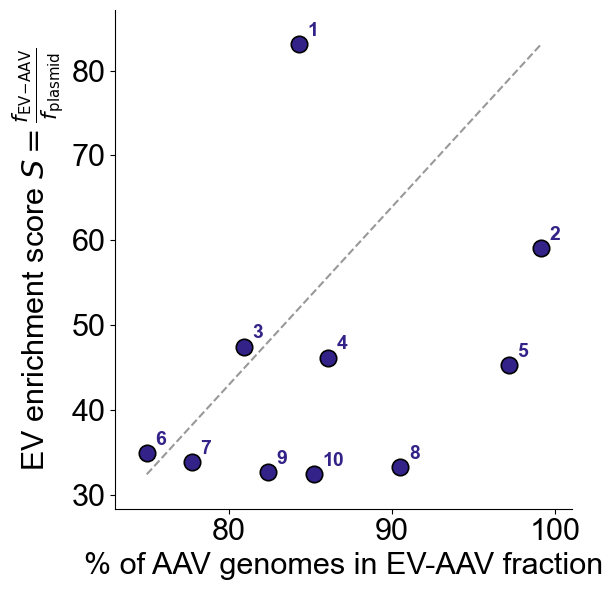

In [3]:
## ML-Assisted DE Approach — EV enrichment score vs. percentage in EV-AAV fraction
# Compares the two metrics for the same top-10 variants:
#   - EV enrichment score        : arithmetic_mean_enrichment (y-axis)
#   - % of AAV genomes in the EV-AAV fraction : pct_ev_mean (x-axis)
# Each point is labeled with the variant's original enrichment-score rank (1 = highest).

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import pearsonr

# ─── ASSEMBLE VALUES ───
val_df = pct_df[["arithmetic_mean_enrichment", "pct_ev_mean"]].copy()
val_df["enrichment_rank"] = np.arange(1, len(val_df) + 1)   # top10_df is already sorted by enrichment score

r, p_value = pearsonr(val_df["pct_ev_mean"], val_df["arithmetic_mean_enrichment"])
print(f"Pearson correlation between EV enrichment score and % EV-AAV fraction: r={r:.2f}, p={p_value:.3f}")

# ─── STYLE CONSTANTS ───
base_fs = 22
rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.titlesize": base_fs,
    "axes.labelsize": base_fs,
    "xtick.labelsize": base_fs,
    "ytick.labelsize": base_fs,
    "legend.fontsize": base_fs,
})

col_point = "#332288"

# ─── AXIS RANGES ───
# Line connects (x_min, y_min) to (x_max, y_max); a small, equal-fraction pad on
# each axis keeps it as the plot's diagonal without clipping the end markers.
x_min, x_max = val_df["pct_ev_mean"].min(), val_df["pct_ev_mean"].max()
y_min, y_max = val_df["arithmetic_mean_enrichment"].min(), val_df["arithmetic_mean_enrichment"].max()
pad_frac = 0.08
x_pad = (x_max - x_min) * pad_frac
y_pad = (y_max - y_min) * pad_frac

# ─── PLOT ───
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot([x_min, x_max], [y_min, y_max], linestyle="--", color="#999999", linewidth=1.5, zorder=1)
ax.scatter(val_df["pct_ev_mean"], val_df["arithmetic_mean_enrichment"],
           s=140, color=col_point, edgecolor="black", linewidth=1.2, zorder=3)

# label each point with its enrichment-score rank (1 = highest)
for _, row in val_df.iterrows():
    ax.annotate(str(int(row["enrichment_rank"])),
                (row["pct_ev_mean"], row["arithmetic_mean_enrichment"]),
                xytext=(6, 6), textcoords="offset points",
                fontsize=14, fontweight="bold", color=col_point, zorder=4)

ax.set_xlabel("% of AAV genomes in EV-AAV fraction", fontsize=base_fs)
ax.set_ylabel(r"EV enrichment score $S = \frac{f_{\mathrm{EV\!-\!AAV}}}{f_{\mathrm{plasmid}}}$", fontsize=base_fs)
ax.set_xlim(x_min - x_pad, x_max + x_pad)
ax.set_ylim(y_min - y_pad, y_max + y_pad)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig('plots/supplementary_figure_S6b.png')
plt.show()

Wild-type 'GSGQNQQ' enrichment scores: rep1=1.50, rep2=1.58, rep3=1.41
Wild-type mean enrichment: 1.50 ± 0.05


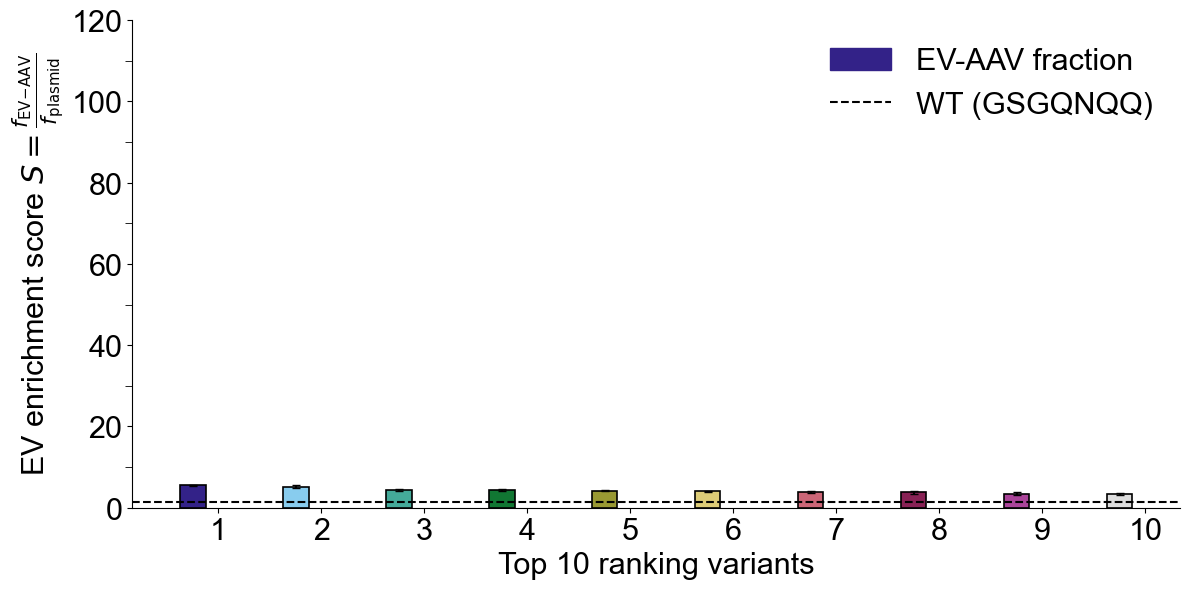

In [4]:
## Directed Evolution Approach - Barplot with Arithmetic Mean and Standard Error

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
from scipy import stats
from matplotlib import rcParams
from matplotlib import colors as mcolors

# ───────────────────── USER SETTINGS ─────────────────────
xlsx_path = (
    "data/Excel/directed_evolution_assessment_library/enrichment_scores_with_amino_acid_sequences.xlsx"
)

rep_cols = [
    "enrichment_score_rep_1",
    "enrichment_score_rep_2",
    "enrichment_score_rep_3",
]

# Paul Tol "Notes" palette
tol_notes = [
    "#332288", "#88CCEE", "#44AA99", "#117733", "#999933",
    "#DDCC77", "#CC6677", "#882255", "#AA4499", "#DDDDDD"
]

# ───────────── LOAD & PREP DATA ─────────────
df = pd.read_excel(xlsx_path)

# Group by amino acid sequence and calculate mean for each replicate
avg_scores = df.groupby('amino_acid_sequence')[rep_cols].mean().reset_index()

# create replicate-specific dataframes including sequence
# and compute ranks based on score only

df_rep1 = avg_scores[['amino_acid_sequence','enrichment_score_rep_1']].copy()
df_rep2 = avg_scores[['amino_acid_sequence','enrichment_score_rep_2']].copy()
df_rep3 = avg_scores[['amino_acid_sequence','enrichment_score_rep_3']].copy()

df_rep1['rank'] = df_rep1['enrichment_score_rep_1'].rank(method='first')
df_rep1.sort_values('rank', ascending=False, inplace=True)
df_rep2['rank'] = df_rep2['enrichment_score_rep_2'].rank(method='first')
df_rep2.sort_values('rank', ascending=False, inplace=True)
df_rep3['rank'] = df_rep3['enrichment_score_rep_3'].rank(method='first')
df_rep3.sort_values('rank', ascending=False, inplace=True)

# merge and keep sequences for each replicate with explicit column names

df_combined = (
    df_rep1.rename(columns={'amino_acid_sequence':'sequence_rep_1'})
    .merge(df_rep2.rename(columns={'amino_acid_sequence':'sequence_rep_2'}), on='rank', how='inner')
    .merge(df_rep3.rename(columns={'amino_acid_sequence':'sequence_rep_3'}), on='rank', how='inner')
)

# Calculate arithmetic mean and standard error across replicates
df_combined["arithmetic_mean_enrichment"] = df_combined[rep_cols].mean(axis=1)
df_combined["std_error"] = df_combined[rep_cols].sem(axis=1)

# Retrieve top ranked variants for statistical testing
top_de_scores = np.array([
    df_combined.iloc[0]["enrichment_score_rep_1"],
    df_combined.iloc[0]["enrichment_score_rep_2"],
    df_combined.iloc[0]["enrichment_score_rep_3"]
])

top10_df = df_combined.head(10).reset_index(drop=True)
ml_scores = np.asarray(top10_df["arithmetic_mean_enrichment"])

# ─── WILD-TYPE REFERENCE ───
wt_seq = "GSGQNQQ"
wt_row = avg_scores[avg_scores['amino_acid_sequence'] == wt_seq]
if not wt_row.empty:
    wt_scores = wt_row[rep_cols].values[0]
    wt_mean = float(wt_scores.mean())
    wt_se = float(wt_scores.std(ddof=1) / np.sqrt(len(wt_scores)))
    print(f"Wild-type '{wt_seq}' enrichment scores: rep1={wt_scores[0]:.2f}, rep2={wt_scores[1]:.2f}, rep3={wt_scores[2]:.2f}")
    print(f"Wild-type mean enrichment: {wt_mean:.2f} ± {wt_se:.2f}")
else:
    wt_mean = None
    print(f"Wild-type sequence '{wt_seq}' not found in DE data.")

# ─────────────── STYLE CONSTANTS ───────────────
base_fs = 22
rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.titlesize": base_fs,
    "axes.labelsize": base_fs,
    "xtick.labelsize": base_fs,
    "ytick.labelsize": base_fs,
    "legend.fontsize": base_fs,
})

# ───────────────────── PLOT ─────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top10_df))
width = 0.25  # width of each bar

def lighten(col, frac):
    return tuple(col[i] + (1-col[i])*frac for i in range(3))

for xi in x:
    col_ev = mcolors.to_rgb(tol_notes[xi])
    ax.bar(xi - width, top10_df.loc[xi, "arithmetic_mean_enrichment"], width,
            color=col_ev, edgecolor="black", linewidth=1.2,
            yerr=top10_df.loc[xi, "std_error"], capsize=3)

if wt_mean is not None:
    ax.axhline(wt_mean, color='black', linestyle='--', linewidth=1.5)

# (scatter points removed)
ax.set_xlabel("Top 10 ranking variants", fontsize=base_fs)
ax.set_ylabel(r"EV enrichment score $S = \frac{f_{\mathrm{EV\!-\!AAV}}}{f_{\mathrm{plasmid}}}$", fontsize=base_fs)
ax.set_xticks(x)
ax.set_xticklabels([f"{i+1}" for i in x])

handles = [mpatches.Patch(color=tol_notes[0], label="EV-AAV fraction")]
if wt_mean is not None:
    handles.append(mlines.Line2D([], [], color='black', linestyle='--', linewidth=1.5, label=f"WT ({wt_seq})"))
legend = ax.legend(handles=handles, frameon=False)

# add minor ticks at specified y-values
minor_ticks = [10, 30, 50, 70, 90, 110]
ax.set_yticks(minor_ticks, minor=True)
ax.tick_params(axis='y', which='minor', length=5)
ax.set_ylim(0, 120)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plots/figure_3a_ii.png')
plt.show()

In [5]:
import numpy as np
from scipy.stats import mannwhitneyu

# One-sided Mann–Whitney U test
u_statistic, p_value = mannwhitneyu(
    top_ml_scores,
    top_de_scores,
    alternative='greater'
)

# Print results
print("Mann–Whitney U statistic:", u_statistic)
print("p-value:", p_value)

# Significance threshold
alpha = 0.05

# Interpret result
if p_value <= alpha:
    print("The difference between groups is statistically significant.")
else:
    print("No statistically significant difference was detected.")

Mann–Whitney U statistic: 9.0
p-value: 0.05
The difference between groups is statistically significant.
